<a href="https://colab.research.google.com/github/shreyas284-crtl/Resume-project-dataset-200k-/blob/main/Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  RESUME SCREENING: SKILLS SCORE PREDICTION & HIRE CLASSIFICATION
All libraries imported successfully.

------------------------------------------------------------
SECTION 5 -> LOAD DATA
------------------------------------------------------------
Dataset Shape  : (200000, 17)
Rows           : 200,000
Columns        : 17

First 5 Rows:
   candidate_id  age education_level university_tier  cgpa  internships  \
0             1   27       Bachelors          Tier 2  8.16            2   
1             2   24       Bachelors          Tier 3  6.35            3   
2             3   33       Bachelors          Tier 3  7.78            0   
3             4   31         Masters          Tier 3  6.92            2   
4             5   28         Masters          Tier 2  8.24            3   

   projects  programming_languages  certifications  experience_years  \
0         7                      2               2              0.33   
1         2                      2               2              4.

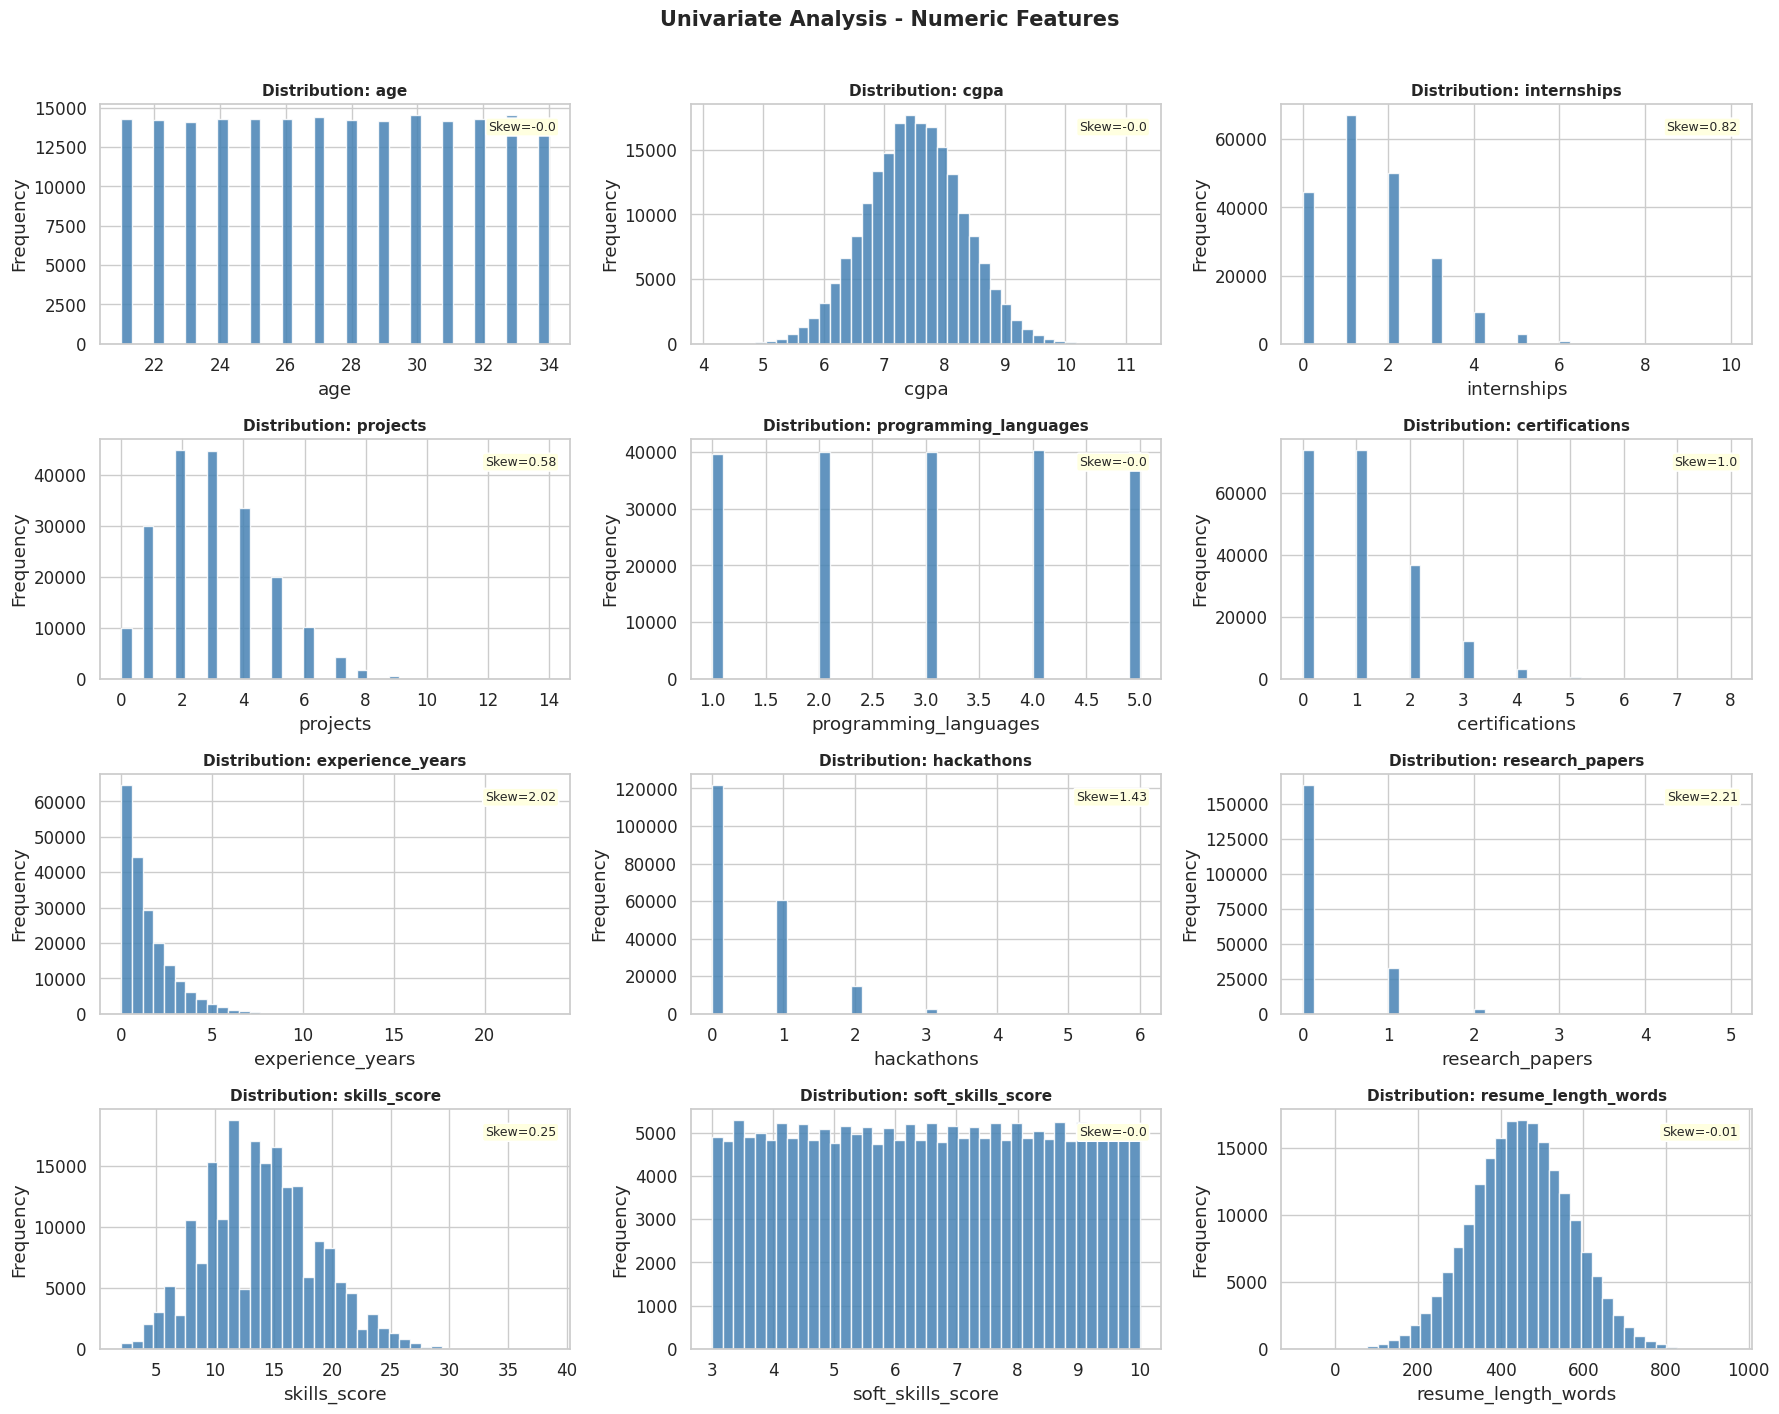

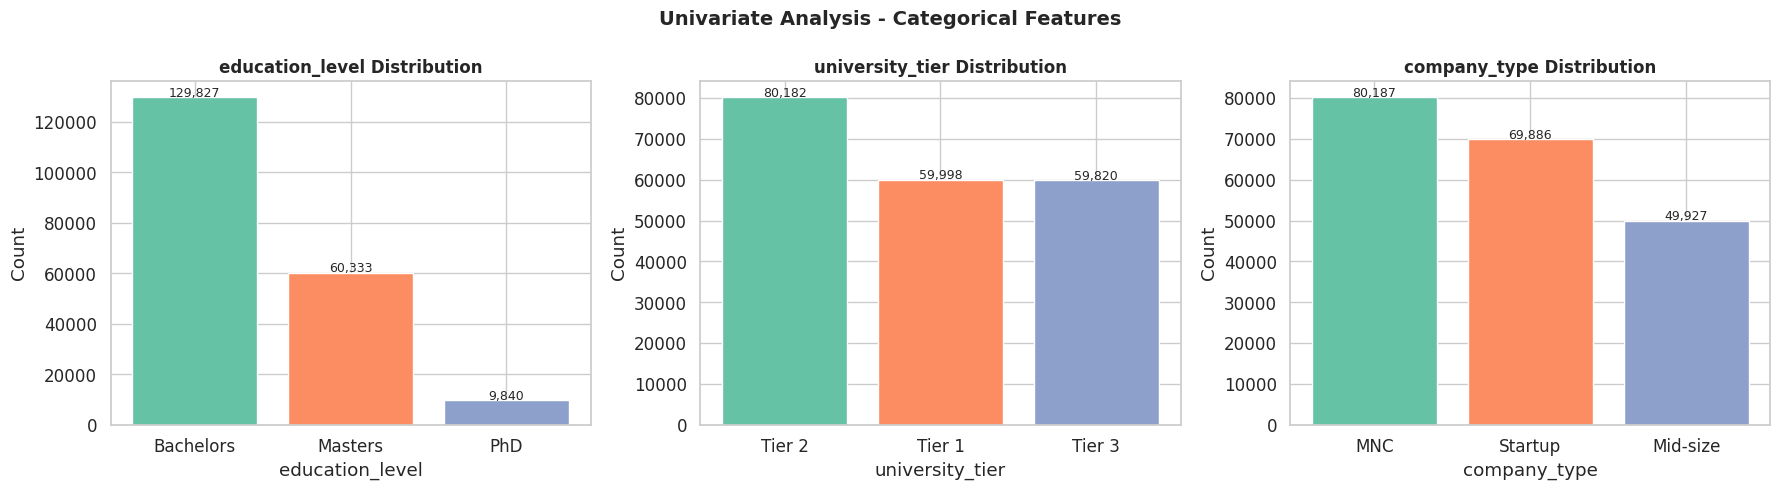

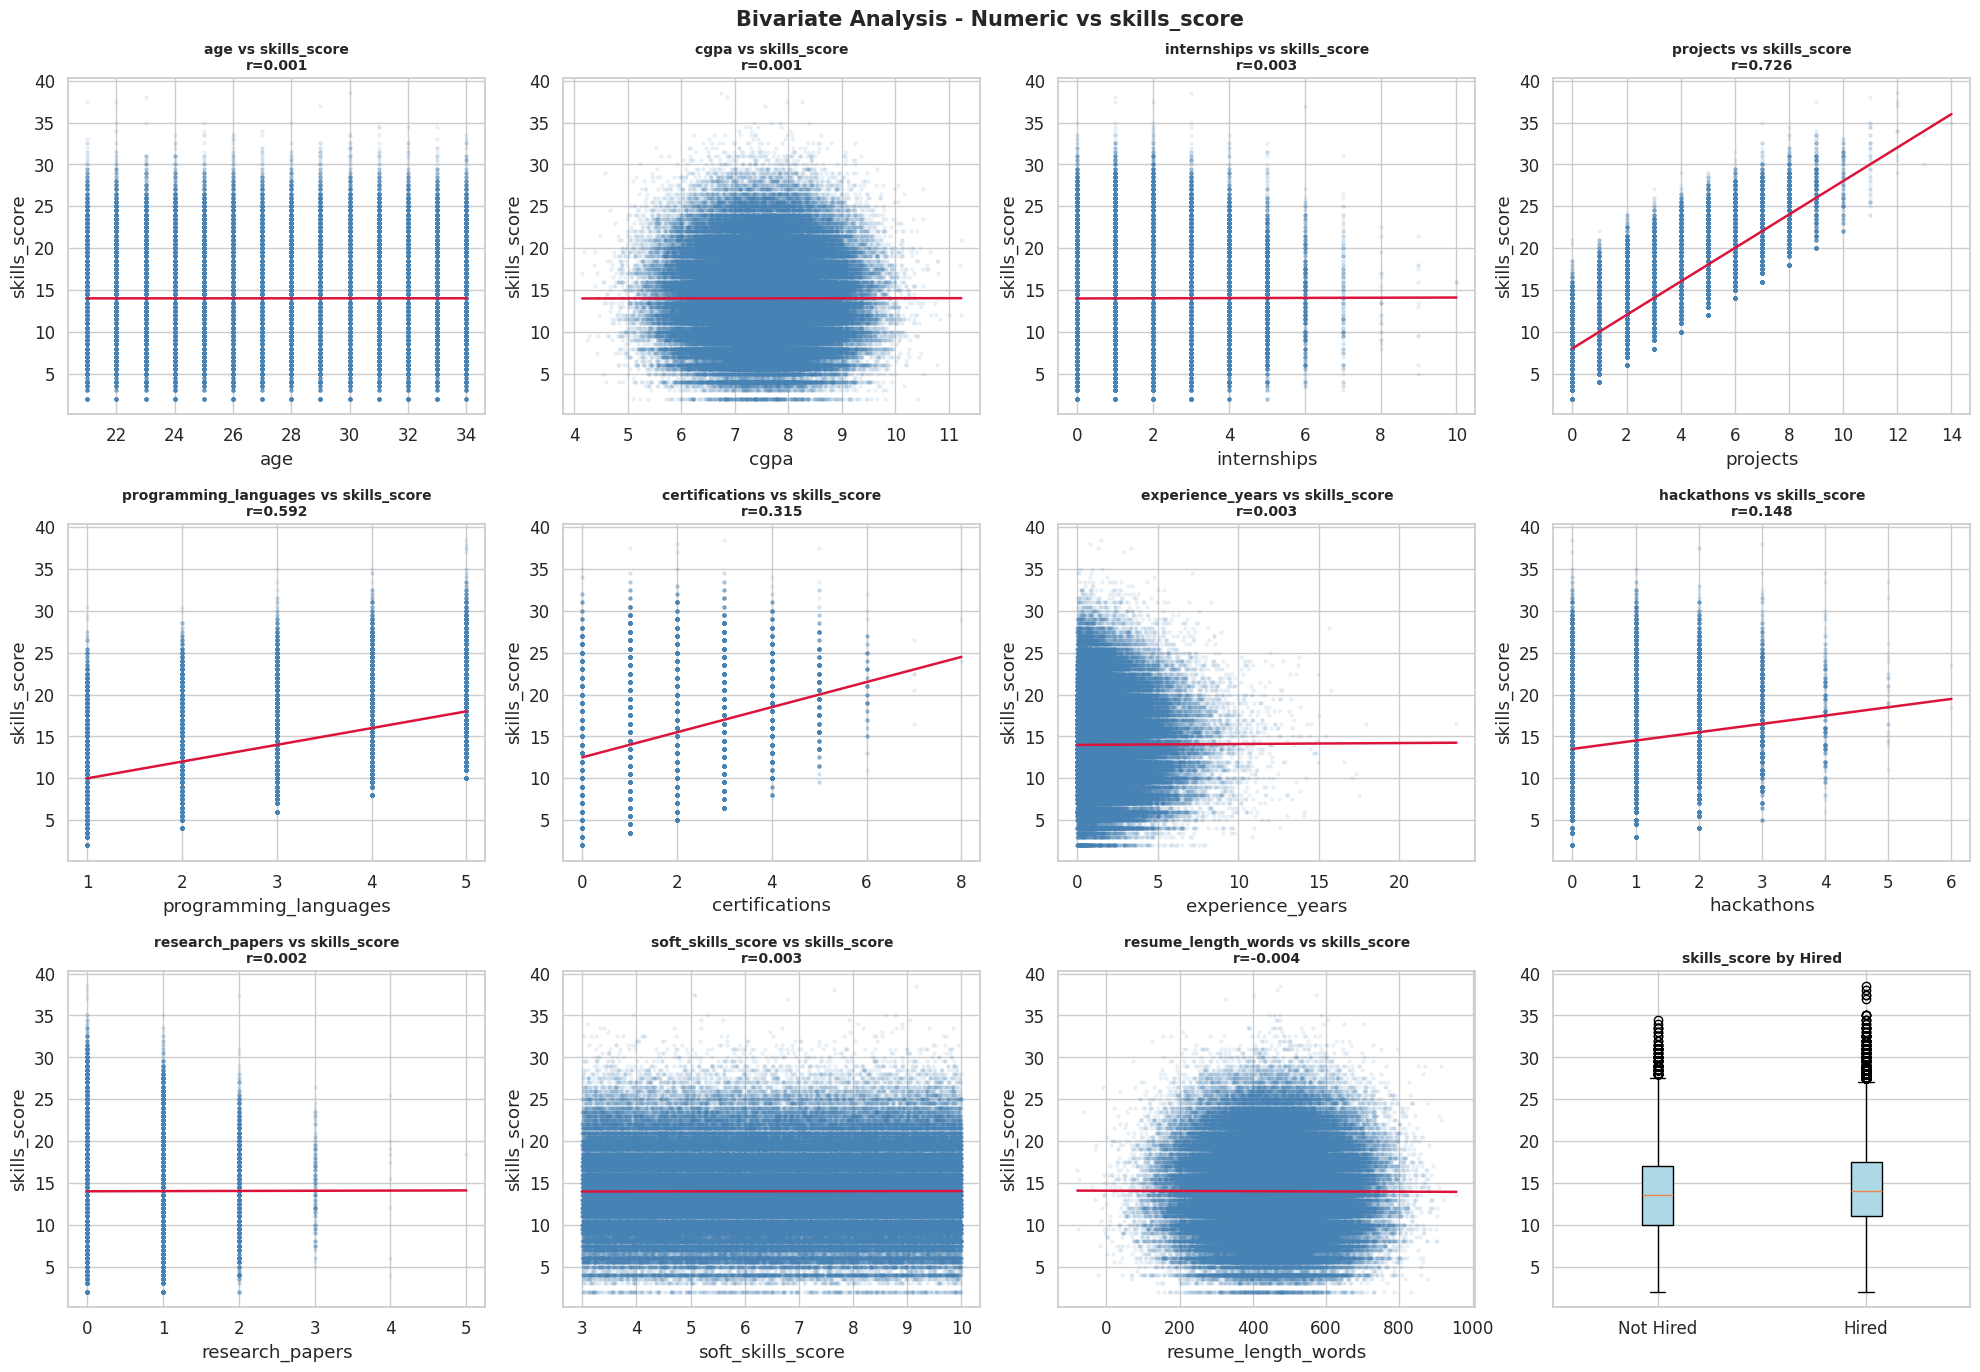

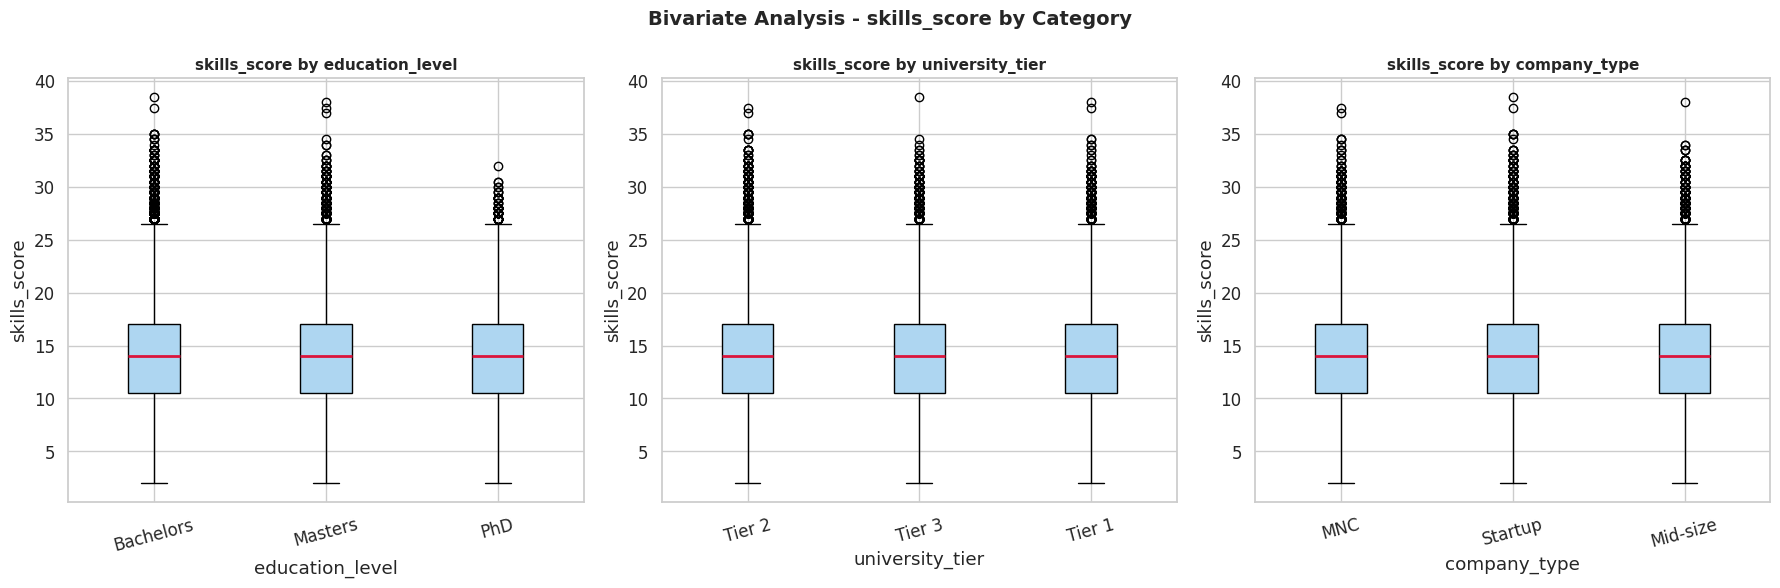

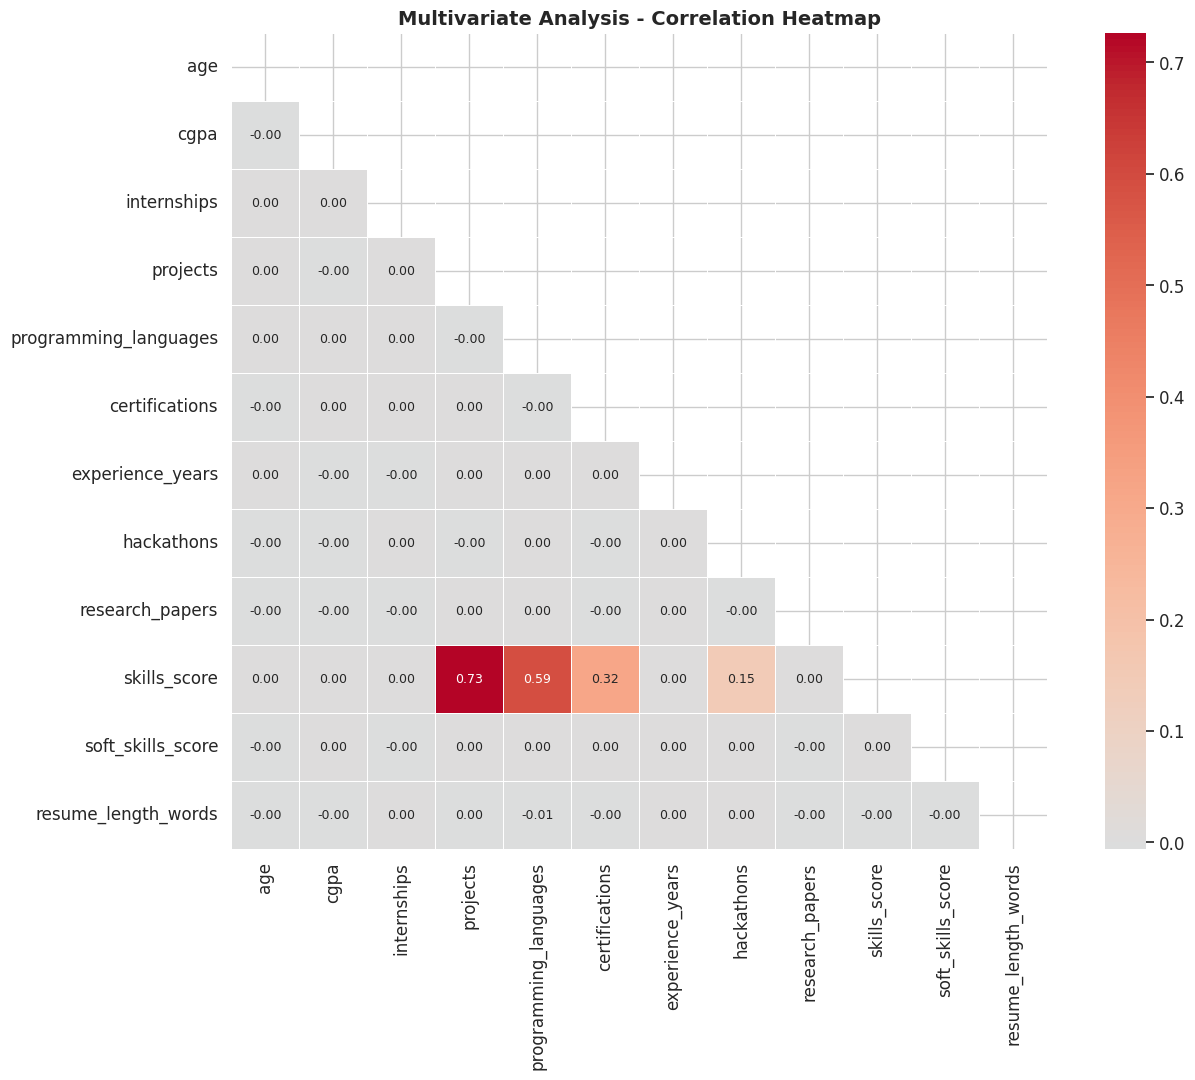

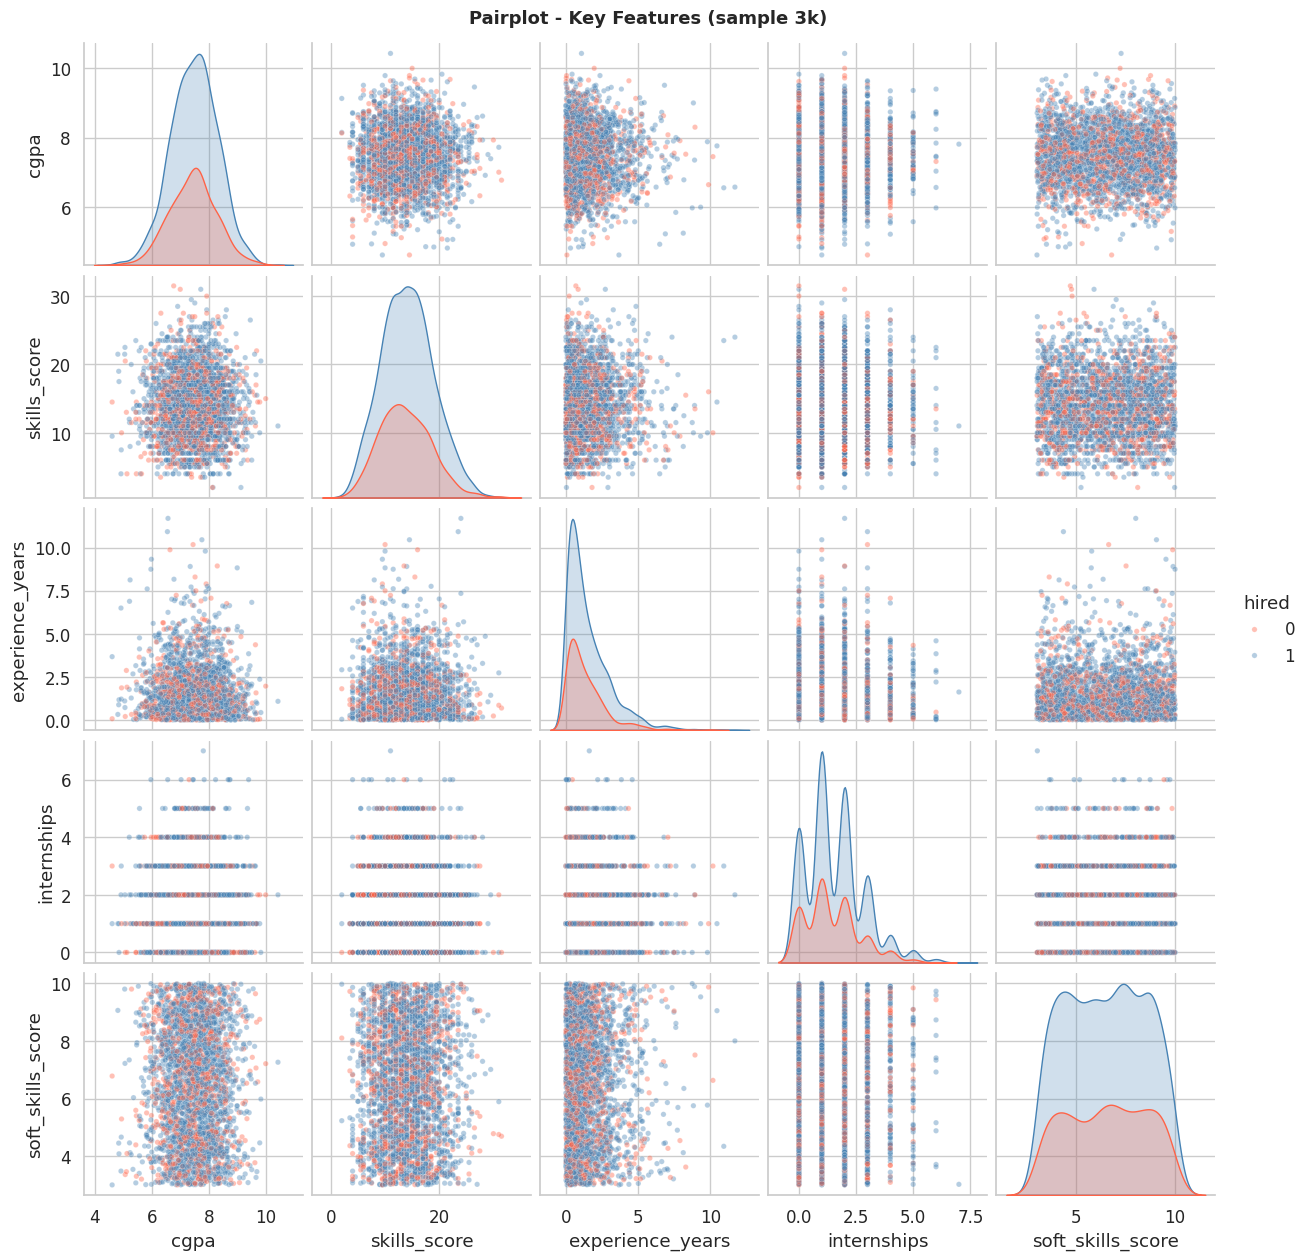

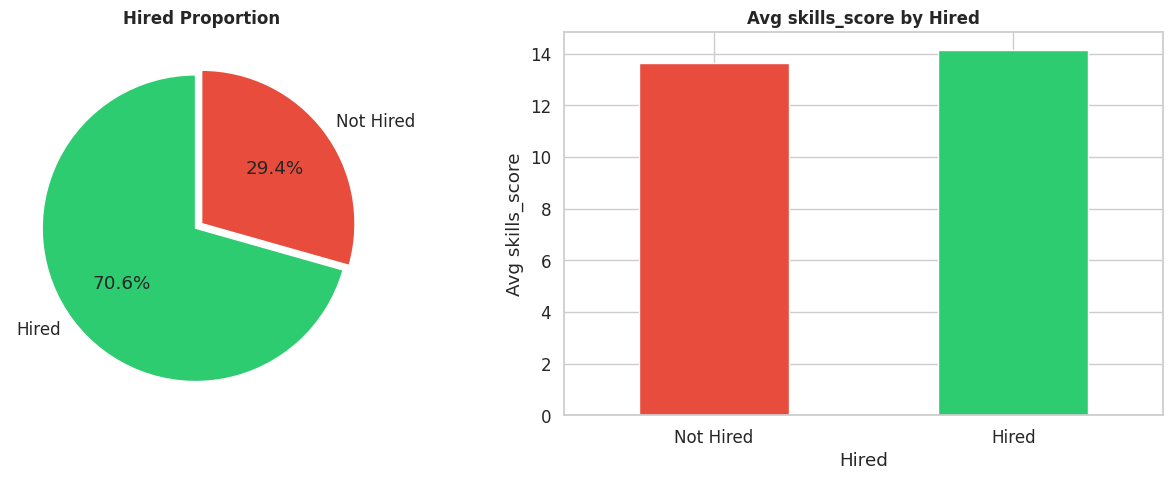


Skewness of numeric columns:
  age                           : -0.004
  cgpa                          : -0.001
  internships                   : 0.818
  projects                      : 0.581
  programming_languages         : -0.005
  certifications                : 1.003
  experience_years              : 2.023
  hackathons                    : 1.429
  research_papers               : 2.215
  skills_score                  : 0.248
  soft_skills_score             : -0.003
  resume_length_words           : -0.01

------------------------------------------------------------
SECTION 10 -> HANDLE OUTLIERS
------------------------------------------------------------


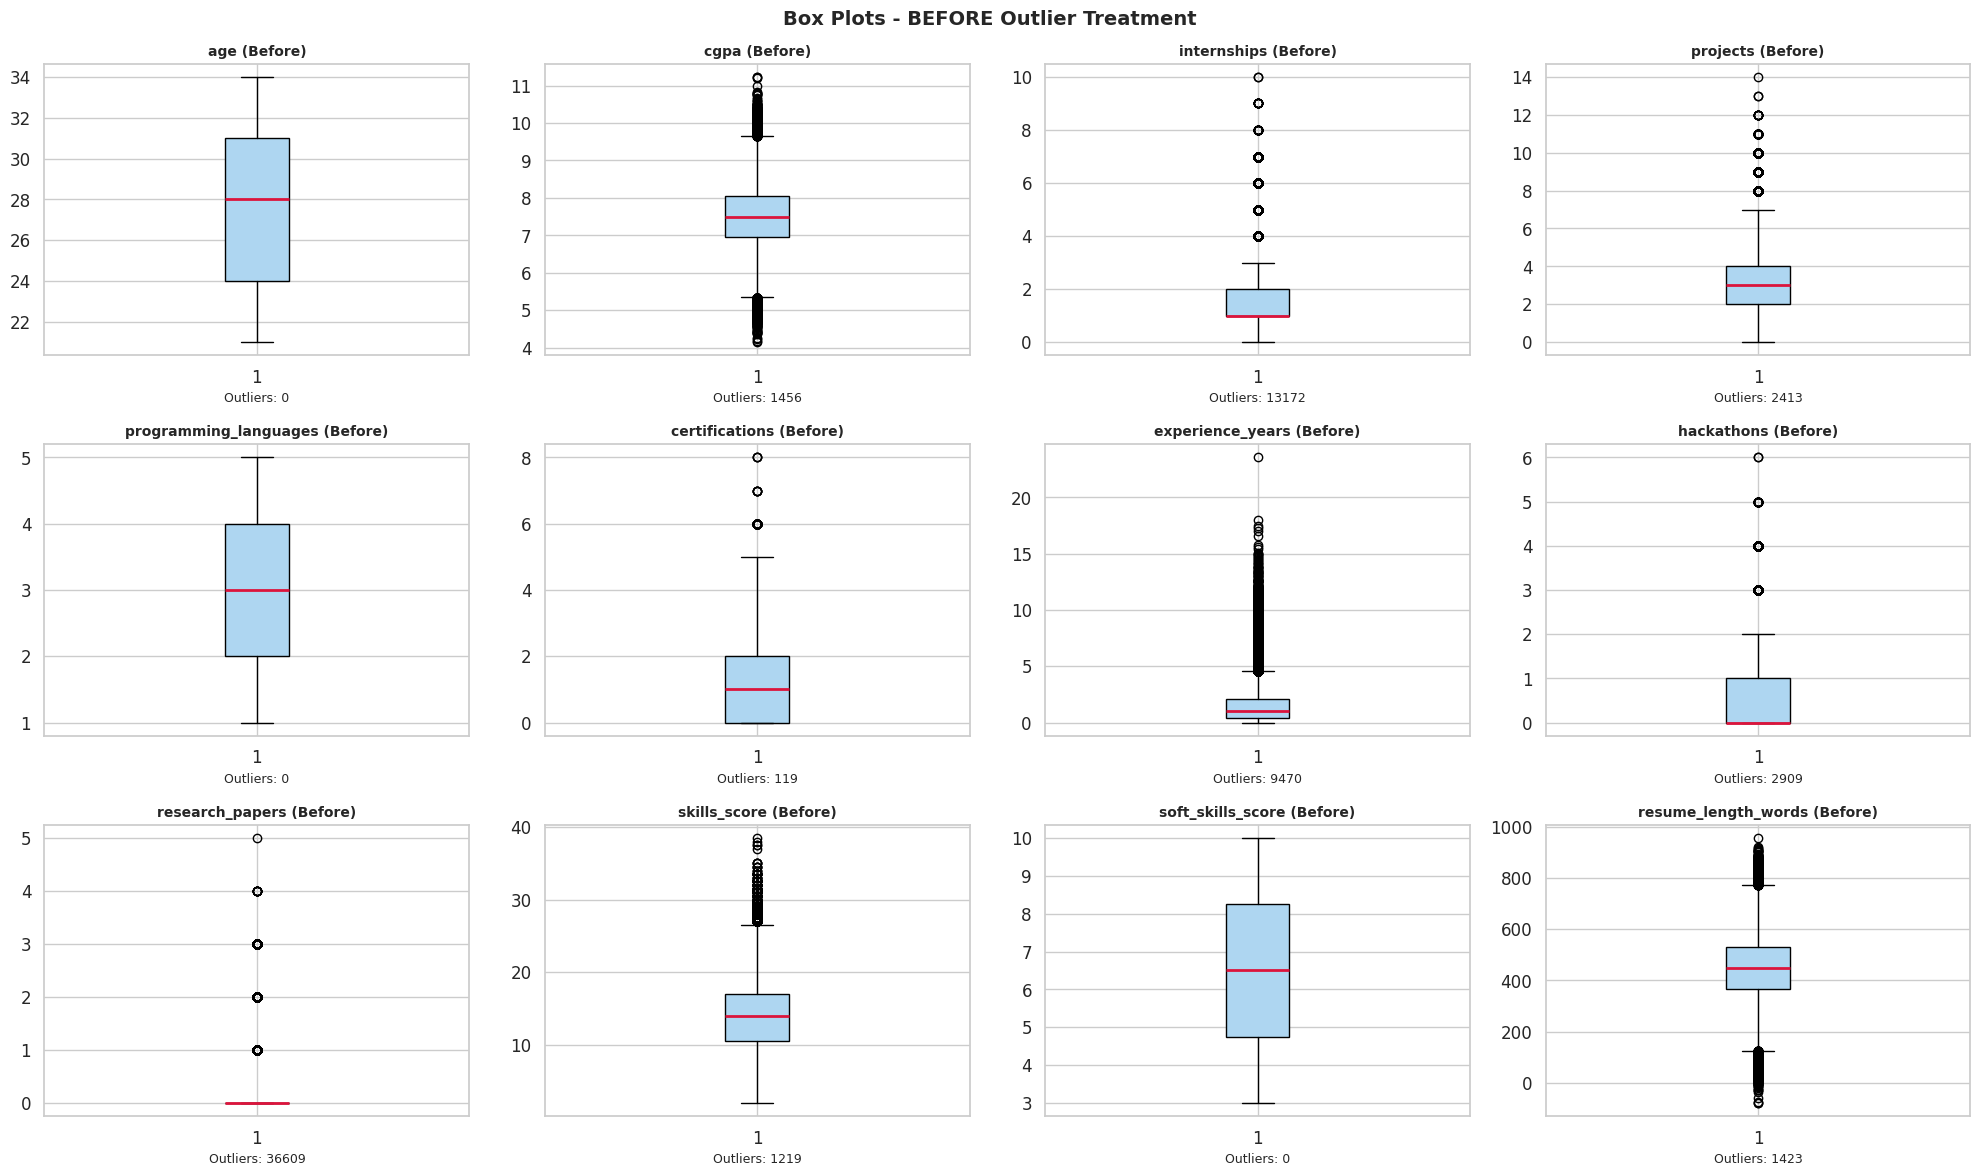

  age                           : 0 outliers capped  [13.5, 41.5]
  cgpa                          : 1456 outliers capped  [5.34, 9.66]
  experience_years              : 9470 outliers capped  [-2.04, 4.56]
  skills_score                  : 1219 outliers capped  [0.75, 26.75]
  soft_skills_score             : 0 outliers capped  [-0.5, 13.5]
  resume_length_words           : 1423 outliers capped  [125.0, 773.0]

Outlier Summary:
             Column  Outliers_Capped  Lower  Upper
                age                0  13.50  41.50
               cgpa             1456   5.34   9.66
   experience_years             9470  -2.04   4.56
       skills_score             1219   0.75  26.75
  soft_skills_score                0  -0.50  13.50
resume_length_words             1423 125.00 773.00


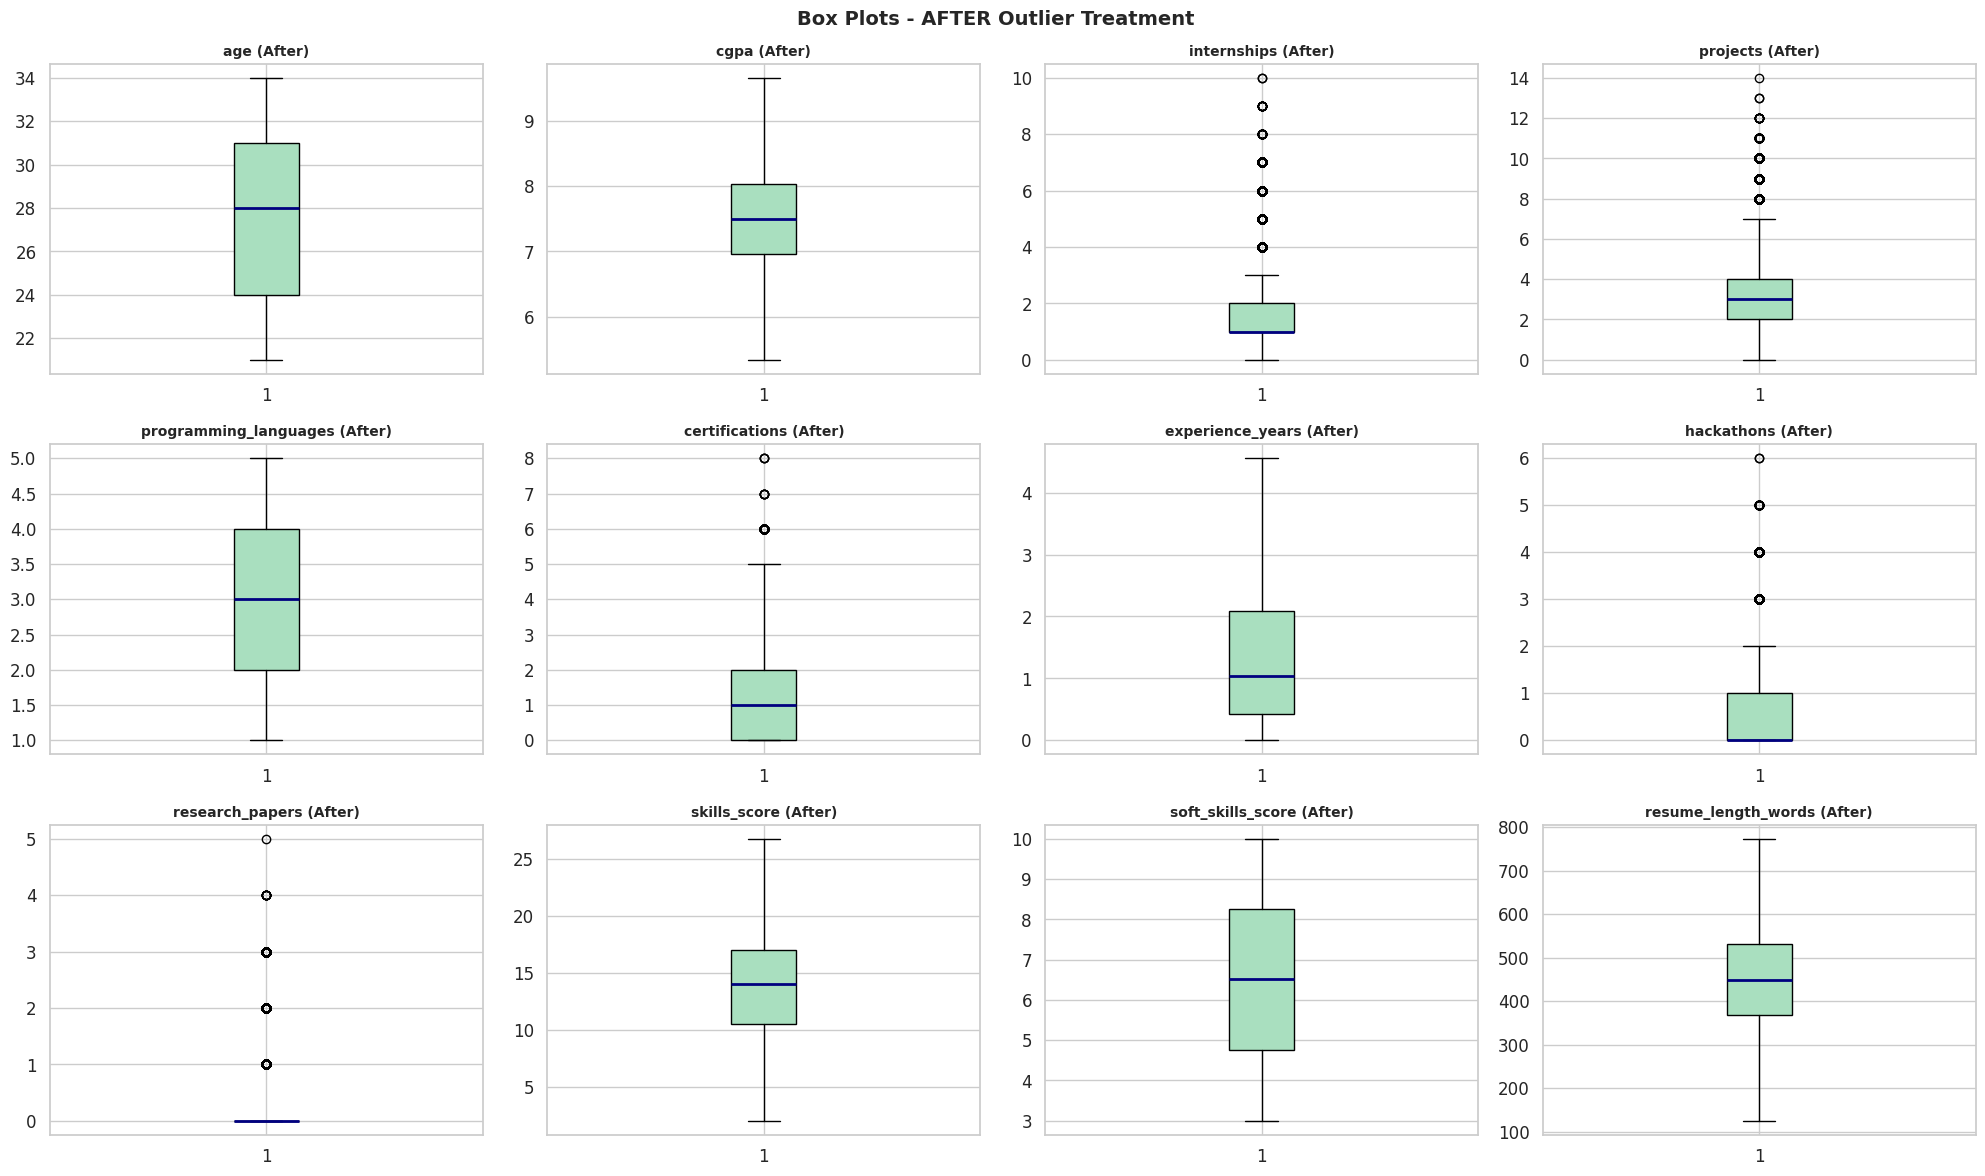


------------------------------------------------------------
SECTION 11 -> ENCODING
------------------------------------------------------------
education_level mapping: {'Bachelors': np.int64(0), 'Masters': np.int64(1), 'PhD': np.int64(2)}
university_tier mapping: {'Tier 1': np.int64(0), 'Tier 2': np.int64(1), 'Tier 3': np.int64(2)}
company_type mapping: {'MNC': np.int64(0), 'Mid-size': np.int64(1), 'Startup': np.int64(2)}
Encoding complete. Shape: (200000, 16)

------------------------------------------------------------
SECTION 12 -> SCALING
------------------------------------------------------------
Features: ['age', 'cgpa', 'internships', 'projects', 'programming_languages', 'certifications', 'experience_years', 'hackathons', 'research_papers', 'soft_skills_score', 'resume_length_words', 'education_level_enc', 'university_tier_enc', 'company_type_enc']
Before scaling (mean/std):
         age   cgpa  internships  projects
mean  27.512  7.499        1.503     2.996
std    4.031  0

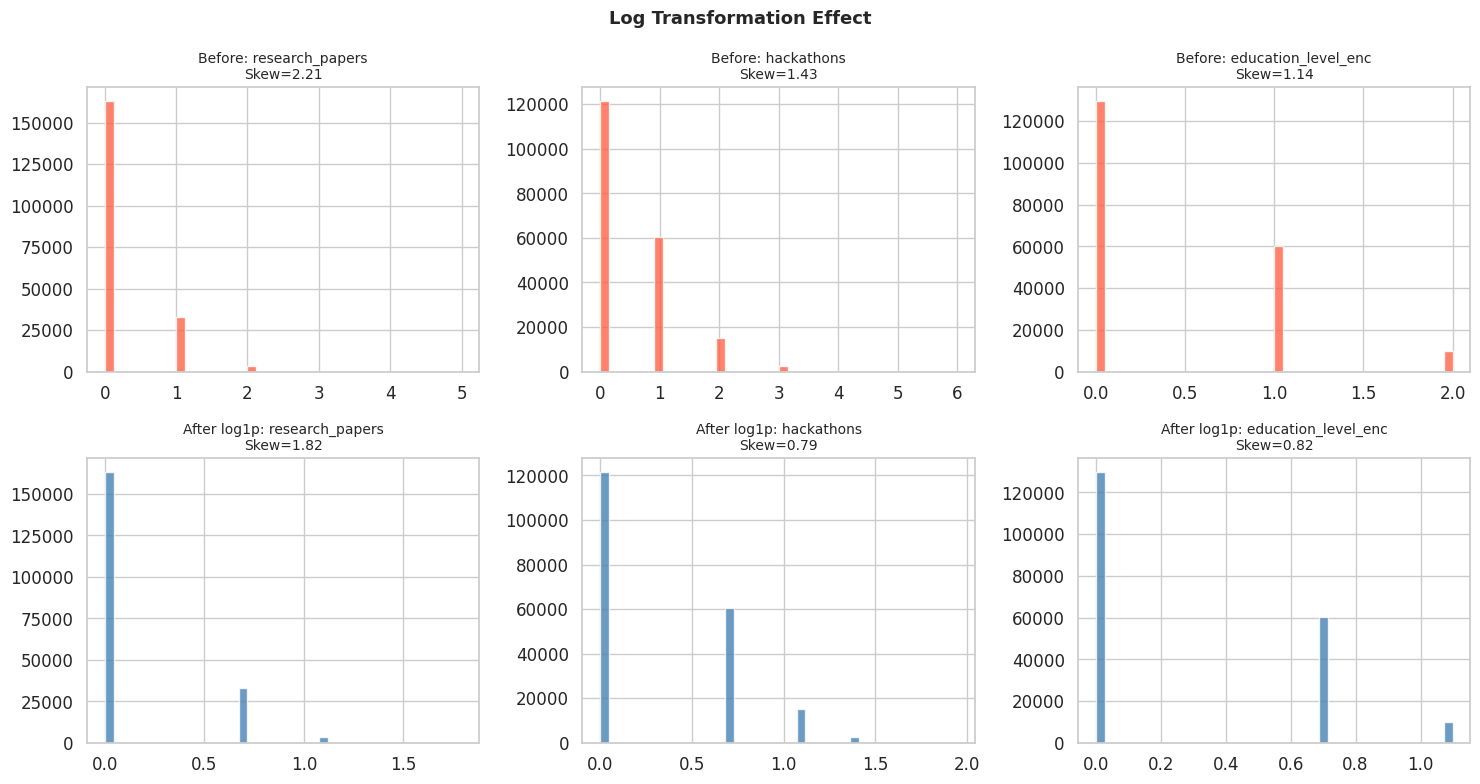


------------------------------------------------------------
SECTION 14 -> FEATURE SELECTION
------------------------------------------------------------
Correlation with skills_score:
 projects                 0.724103
programming_languages    0.594083
certifications           0.314862
hackathons               0.147495
resume_length_words      0.003902
soft_skills_score        0.003364
experience_years         0.003091
internships              0.002575
research_papers          0.002111
company_type_enc         0.001634
age                      0.000833
cgpa                     0.000704
university_tier_enc      0.000666
education_level_enc      0.000304
dtype: float64

SelectKBest (Regression):
               Feature       F_Score  P_Value
             projects 220452.839777 0.000000
programming_languages 109086.880359 0.000000
       certifications  22009.374250 0.000000
           hackathons   4447.657119 0.000000
  resume_length_words      3.045702 0.080953
    soft_skills_score   

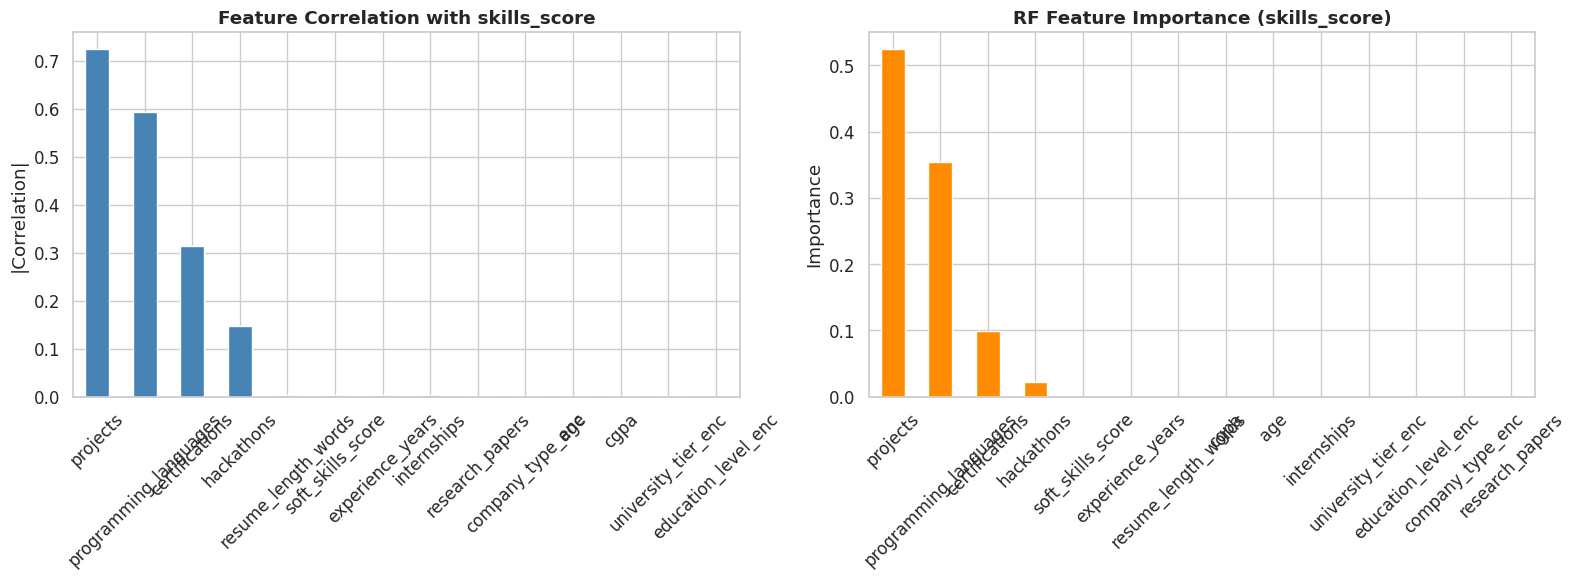


Top Regression Features   : ['projects', 'programming_languages', 'certifications', 'hackathons', 'resume_length_words', 'soft_skills_score', 'experience_years']
Top Classification Features: ['experience_years', 'internships', 'projects', 'programming_languages', 'certifications', 'cgpa', 'hackathons']

------------------------------------------------------------
SECTION 15 -> SPLIT X AND Y
------------------------------------------------------------
X_reg   shape: (200000, 7)
X_class shape: (200000, 7)

------------------------------------------------------------
SECTION 16 -> TRAIN-TEST SPLIT (80:20)
------------------------------------------------------------
Regression   -> Train: (160000, 7), Test: (40000, 7)
Classification -> Train: (160000, 7), Test: (40000, 7)
Class balance in train: {1: 112970, 0: 47030}

------------------------------------------------------------
SECTION 17 -> IMPLEMENT MODELS
------------------------------------------------------------

Training Regression

In [ ]:
# ============================================================
# REGRESSION PROJECT - RESUME DATASET (200K Records)
# ============================================================
# Target Variable: skills_score (Regression)
# Secondary Target: hired (Classification)
# ============================================================

# ─────────────────────────────────────────────────────────────
# SECTION 1: PROJECT TITLE
# ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  RESUME SCREENING: SKILLS SCORE PREDICTION & HIRE CLASSIFICATION")
print("=" * 65)

# ─────────────────────────────────────────────────────────────
# SECTION 2: PROBLEM STATEMENT
# ─────────────────────────────────────────────────────────────
"""
Problem Statement:
------------------
Recruitment teams receive thousands of resumes daily. Manually scoring
candidates is time-consuming and subjective. This project builds:
  1. A Regression model  -> predict a candidate's skills_score
  2. A Classification model -> predict whether a candidate will be hired

By automating these predictions, companies can shortlist candidates
faster and reduce bias in early screening.
"""

# ─────────────────────────────────────────────────────────────
# SECTION 3: OBJECTIVE
# ─────────────────────────────────────────────────────────────
"""
Objectives:
-----------
1. Perform complete EDA on 200,000 resume records.
2. Clean, encode, and scale the data properly.
3. Apply log transformation where required.
4. Train and evaluate multiple regression models for skills_score.
5. Train and evaluate multiple classification models for hired.
6. Compare models using R2, MAE, RMSE (regression) and
   Accuracy, F1, ROC-AUC (classification).
7. Visualize insights at every stage.
"""

# ─────────────────────────────────────────────────────────────
# SECTION 4: IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, f_regression, f_classif

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics - Regression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
# Metrics - Classification
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc)

import pickle, os

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("All libraries imported successfully.")

# ─────────────────────────────────────────────────────────────
# SECTION 5: LOAD DATA
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 5 -> LOAD DATA")
print("-"*60)

df = pd.read_csv('resume_dataset_200k_enhanced.csv')
print(f"Dataset Shape  : {df.shape}")
print(f"Rows           : {df.shape[0]:,}")
print(f"Columns        : {df.shape[1]}")
print("\nFirst 5 Rows:")
print(df.head())

# ─────────────────────────────────────────────────────────────
# SECTION 6: DOMAIN ANALYSIS / UNDERSTAND VARIABLES
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 6 -> DOMAIN ANALYSIS")
print("-"*60)

print("""
VARIABLE DESCRIPTIONS
-------------------------------------------------------------
candidate_id          -> Unique ID (drop before modelling)
age                   -> Age of candidate (numeric)
education_level       -> Bachelors / Masters / PhD (categorical)
university_tier       -> Tier 1 / Tier 2 / Tier 3 (categorical)
cgpa                  -> Grade Point Average 0-10 (numeric)
internships           -> Number of internships completed (numeric)
projects              -> Number of projects done (numeric)
programming_languages -> Number of languages known (numeric)
certifications        -> Number of certifications earned (numeric)
experience_years      -> Years of work experience (numeric)
hackathons            -> Number of hackathons participated (numeric)
research_papers       -> Number of papers published (numeric)
skills_score          -> REGRESSION TARGET - overall skill rating
hired                 -> CLASSIFICATION TARGET - 1=Hired, 0=Not Hired
soft_skills_score     -> Soft skills rating (numeric)
resume_length_words   -> Word count of resume (numeric)
company_type          -> MNC / Startup / Government (categorical)
-------------------------------------------------------------
""")

print("Data Types:\n", df.dtypes)
print("\nStatistical Summary (Numeric):")
print(df.describe().round(2))
print("\nStatistical Summary (Categorical):")
print(df.describe(include='object'))

# ─────────────────────────────────────────────────────────────
# SECTION 7: BASIC CHECKS
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 7 -> BASIC CHECKS")
print("-"*60)

print("Shape           :", df.shape)
print("Null Values:\n", df.isnull().sum())
print("\nDuplicate Rows  :", df.duplicated().sum())

print("\nUnique Values per Column:")
for col in df.columns:
    print(f"  {col:30s}: {df[col].nunique()}")

print("\nTarget (skills_score) range:", df['skills_score'].min(), "-", df['skills_score'].max())
print("Target (hired) distribution:\n", df['hired'].value_counts())
print("Hired %:", round(df['hired'].mean()*100, 2))

# ─────────────────────────────────────────────────────────────
# SECTION 8: DATA CLEANING
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 8 -> DATA CLEANING")
print("-"*60)

df.drop(columns=['candidate_id'], inplace=True)
print("Dropped 'candidate_id' column.")

print("Missing values:", df.isnull().sum().sum())
if df.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(include='object').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values imputed.")

dups = df.duplicated().sum()
print(f"Duplicate rows : {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {dups} duplicate rows.")
else:
    print("No duplicates found.")

print(f"\nDataset after cleaning: {df.shape}")

# ─────────────────────────────────────────────────────────────
# SECTION 9: EDA
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 9 -> EDA (Univariate | Bivariate | Multivariate)")
print("-"*60)

num_features = ['age', 'cgpa', 'internships', 'projects', 'programming_languages',
                'certifications', 'experience_years', 'hackathons',
                'research_papers', 'skills_score', 'soft_skills_score',
                'resume_length_words']
cat_features = ['education_level', 'university_tier', 'company_type']

# 9A. Univariate - Histograms
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    skw = round(skew(df[col].dropna()), 2)
    axes[i].text(0.97, 0.93, f'Skew={skw}', ha='right', va='top',
                 transform=axes[i].transAxes, fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow'))
plt.suptitle("Univariate Analysis - Numeric Features", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_univariate_histograms.png", bbox_inches='tight', dpi=120)
plt.show()

# 9B. Univariate - Categorical
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_features):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=sns.color_palette("Set2", len(vc)), edgecolor='white')
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 200, f'{v:,}', ha='center', fontsize=9)
plt.suptitle("Univariate Analysis - Categorical Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_univariate_categorical.png", bbox_inches='tight', dpi=120)
plt.show()

# 9C. Bivariate - scatter vs skills_score
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
predictors = [c for c in num_features if c != 'skills_score']
for i, col in enumerate(predictors):
    axes[i].scatter(df[col], df['skills_score'], alpha=0.08,
                    color='steelblue', s=5, rasterized=True)
    m, b = np.polyfit(df[col], df['skills_score'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='crimson', linewidth=1.8)
    corr = round(df[col].corr(df['skills_score']), 3)
    axes[i].set_title(f'{col} vs skills_score\nr={corr}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('skills_score')
axes[-1].boxplot([df[df['hired']==0]['skills_score'],
                  df[df['hired']==1]['skills_score']],
                 labels=['Not Hired', 'Hired'], patch_artist=True,
                 boxprops=dict(facecolor='lightblue'))
axes[-1].set_title('skills_score by Hired', fontsize=10, fontweight='bold')
plt.suptitle("Bivariate Analysis - Numeric vs skills_score", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_bivariate_scatter.png", bbox_inches='tight', dpi=120)
plt.show()

# 9D. Bivariate - boxplots by category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, col in enumerate(cat_features):
    groups = [df[df[col]==g]['skills_score'].values for g in df[col].unique()]
    axes[i].boxplot(groups, labels=df[col].unique(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1'), medianprops=dict(color='crimson', linewidth=2))
    axes[i].set_title(f'skills_score by {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('skills_score')
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle("Bivariate Analysis - skills_score by Category", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_bivariate_categorical_boxplot.png", bbox_inches='tight', dpi=120)
plt.show()

# 9E. Multivariate - Correlation Heatmap
corr_df = df[num_features].corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True, annot_kws={"size": 9})
ax.set_title("Multivariate Analysis - Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_correlation_heatmap.png", bbox_inches='tight', dpi=120)
plt.show()

# 9F. Pairplot
pair_cols = ['cgpa', 'skills_score', 'experience_years', 'internships', 'soft_skills_score', 'hired']
sample_df = df[pair_cols].sample(3000, random_state=42)
g = sns.pairplot(sample_df, hue='hired', diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 palette={0: 'tomato', 1: 'steelblue'})
g.fig.suptitle("Pairplot - Key Features (sample 3k)", y=1.01, fontsize=13, fontweight='bold')
plt.savefig(f"{OUTPUT_DIR}/06_pairplot.png", bbox_inches='tight', dpi=100)
plt.show()

# 9G. Hired distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
hired_counts = df['hired'].value_counts()
axes[0].pie(hired_counts.values, labels=['Hired', 'Not Hired'],
            autopct='%1.1f%%', colors=['#2ECC71', '#E74C3C'],
            startangle=90, explode=(0.05, 0))
axes[0].set_title('Hired Proportion', fontsize=12, fontweight='bold')
df.groupby('hired')['skills_score'].mean().plot(kind='bar', ax=axes[1],
    color=['#E74C3C', '#2ECC71'], edgecolor='white', width=0.5)
axes[1].set_title('Avg skills_score by Hired', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hired')
axes[1].set_ylabel('Avg skills_score')
axes[1].set_xticklabels(['Not Hired', 'Hired'], rotation=0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_hired_analysis.png", bbox_inches='tight', dpi=120)
plt.show()

print("\nSkewness of numeric columns:")
for col in num_features:
    print(f"  {col:30s}: {round(skew(df[col]), 3)}")

# ─────────────────────────────────────────────────────────────
# SECTION 10: HANDLE OUTLIERS
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 10 -> HANDLE OUTLIERS")
print("-"*60)

# Boxplots BEFORE
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1'),
                    medianprops=dict(color='crimson', linewidth=2))
    axes[i].set_title(f'{col} (Before)', fontsize=10, fontweight='bold')
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    axes[i].set_xlabel(f'Outliers: {n_out}', fontsize=9)
plt.suptitle("Box Plots - BEFORE Outlier Treatment", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_boxplots_before_outliers.png", bbox_inches='tight', dpi=120)
plt.show()

# IQR Capping
continuous_for_cap = ['age', 'cgpa', 'experience_years', 'skills_score',
                      'soft_skills_score', 'resume_length_words']
df_cleaned = df.copy()
outlier_summary = []
for col in continuous_for_cap:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df_cleaned[col] < lower) | (df_cleaned[col] > upper)).sum()
    df_cleaned[col] = df_cleaned[col].clip(lower, upper)
    outlier_summary.append({'Column': col, 'Outliers_Capped': before,
                             'Lower': round(lower,2), 'Upper': round(upper,2)})
    print(f"  {col:30s}: {before} outliers capped  [{round(lower,2)}, {round(upper,2)}]")

print("\nOutlier Summary:")
print(pd.DataFrame(outlier_summary).to_string(index=False))

# Boxplots AFTER
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].boxplot(df_cleaned[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#A9DFBF'),
                    medianprops=dict(color='navy', linewidth=2))
    axes[i].set_title(f'{col} (After)', fontsize=10, fontweight='bold')
plt.suptitle("Box Plots - AFTER Outlier Treatment", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_boxplots_after_outliers.png", bbox_inches='tight', dpi=120)
plt.show()

df = df_cleaned.copy()

# ─────────────────────────────────────────────────────────────
# SECTION 11: ENCODING
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 11 -> ENCODING")
print("-"*60)

le = LabelEncoder()
df['education_level_enc'] = le.fit_transform(df['education_level'])
print("education_level mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

df['university_tier_enc'] = le.fit_transform(df['university_tier'])
print("university_tier mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

df['company_type_enc'] = le.fit_transform(df['company_type'])
print("company_type mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

df.drop(columns=cat_features, inplace=True)
print("Encoding complete. Shape:", df.shape)

# ─────────────────────────────────────────────────────────────
# SECTION 12: SCALING
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 12 -> SCALING")
print("-"*60)

TARGET_REG   = 'skills_score'
TARGET_CLASS = 'hired'

feature_cols = [c for c in df.columns if c not in [TARGET_REG, TARGET_CLASS]]
print("Features:", feature_cols)

scaler = StandardScaler()
df_scaled_features = pd.DataFrame(
    scaler.fit_transform(df[feature_cols]),
    columns=feature_cols
)
df_scaled_features[TARGET_REG]   = df[TARGET_REG].values
df_scaled_features[TARGET_CLASS] = df[TARGET_CLASS].values

print("Before scaling (mean/std):")
print(df[feature_cols[:4]].agg(['mean','std']).round(3))
print("After scaling (mean/std):")
print(df_scaled_features[feature_cols[:4]].agg(['mean','std']).round(3))

# ─────────────────────────────────────────────────────────────
# SECTION 13: LOG TRANSFORMATION
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 13 -> LOG TRANSFORMATION")
print("-"*60)

skew_series = df[feature_cols].apply(skew).sort_values(ascending=False)
print("Skewness:\n", skew_series)

skewed_cols = skew_series[skew_series > 0.75].index.tolist()
print(f"\nApplying log1p to: {skewed_cols}")

df_log = df.copy()
for col in skewed_cols:
    if df_log[col].min() >= 0:
        df_log[col] = np.log1p(df_log[col])

# Plot before/after
fig, axes = plt.subplots(2, min(3, len(skewed_cols)), figsize=(15, 8))
for i, col in enumerate(skewed_cols[:3]):
    axes[0, i].hist(df[col], bins=40, color='tomato', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'Before: {col}\nSkew={round(skew(df[col]),2)}', fontsize=10)
    axes[1, i].hist(df_log[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'After log1p: {col}\nSkew={round(skew(df_log[col]),2)}', fontsize=10)
plt.suptitle("Log Transformation Effect", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/10_log_transformation.png", bbox_inches='tight', dpi=120)
plt.show()

df_model = df_scaled_features.copy()
for col in skewed_cols:
    if col in df_model.columns and df_model[col].min() >= 0:
        df_model[col] = np.log1p(df_model[col])

# ─────────────────────────────────────────────────────────────
# SECTION 14: FEATURE SELECTION
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 14 -> FEATURE SELECTION")
print("-"*60)

X = df_model[feature_cols]
y_reg   = df_model[TARGET_REG]
y_class = df_model[TARGET_CLASS]

# Correlation with target
corr_with_target = X.corrwith(y_reg).abs().sort_values(ascending=False)
print("Correlation with skills_score:\n", corr_with_target)

# SelectKBest - Regression
selector_reg = SelectKBest(score_func=f_regression, k='all')
selector_reg.fit(X, y_reg)
reg_scores = pd.DataFrame({'Feature': feature_cols,
                            'F_Score': selector_reg.scores_,
                            'P_Value': selector_reg.pvalues_}).sort_values('F_Score', ascending=False)
print("\nSelectKBest (Regression):\n", reg_scores.to_string(index=False))

# SelectKBest - Classification
selector_cls = SelectKBest(score_func=f_classif, k='all')
selector_cls.fit(X, y_class)
cls_scores = pd.DataFrame({'Feature': feature_cols,
                            'F_Score': selector_cls.scores_,
                            'P_Value': selector_cls.pvalues_}).sort_values('F_Score', ascending=False)
print("\nSelectKBest (Classification):\n", cls_scores.to_string(index=False))

# RF Feature Importance
rf_importance = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_importance.fit(X, y_reg)
feat_imp = pd.Series(rf_importance.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
corr_with_target.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Feature Correlation with skills_score', fontweight='bold')
axes[0].set_ylabel('|Correlation|')
axes[0].tick_params(axis='x', rotation=45)
feat_imp.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('RF Feature Importance (skills_score)', fontweight='bold')
axes[1].set_ylabel('Importance')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/11_feature_selection.png", bbox_inches='tight', dpi=120)
plt.show()

top_reg_features   = reg_scores[reg_scores['F_Score'] > reg_scores['F_Score'].median()]['Feature'].tolist()
top_class_features = cls_scores[cls_scores['F_Score'] > cls_scores['F_Score'].median()]['Feature'].tolist()
print(f"\nTop Regression Features   : {top_reg_features}")
print(f"Top Classification Features: {top_class_features}")

# ─────────────────────────────────────────────────────────────
# SECTION 15: SPLIT X AND Y
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 15 -> SPLIT X AND Y")
print("-"*60)

X_reg   = df_model[top_reg_features]
X_class = df_model[top_class_features]
print(f"X_reg   shape: {X_reg.shape}")
print(f"X_class shape: {X_class.shape}")

# ─────────────────────────────────────────────────────────────
# SECTION 16: TRAIN-TEST SPLIT
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 16 -> TRAIN-TEST SPLIT (80:20)")
print("-"*60)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class)

print(f"Regression   -> Train: {X_train_r.shape}, Test: {X_test_r.shape}")
print(f"Classification -> Train: {X_train_c.shape}, Test: {X_test_c.shape}")
print(f"Class balance in train: {y_train_c.value_counts().to_dict()}")

# ─────────────────────────────────────────────────────────────
# SECTION 17: IMPLEMENT MODELS
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 17 -> IMPLEMENT MODELS")
print("-"*60)

# ── 17A. REGRESSION MODELS ──
reg_models = {
    'Linear Regression'       : LinearRegression(),
    'Ridge Regression'        : Ridge(alpha=1.0),
    'Lasso Regression'        : Lasso(alpha=0.01),
    'ElasticNet'              : ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Decision Tree Regressor' : DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest Regressor' : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting Reg'   : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Extra Trees Regressor'   : ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN Regressor'           : KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
}

reg_results = []
print("\nTraining Regression Models...")
for name, model in reg_models.items():
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)
    mae  = mean_absolute_error(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2   = r2_score(y_test_r, y_pred)
    mape = mean_absolute_percentage_error(y_test_r, y_pred) * 100
    cv   = cross_val_score(model, X_reg, y_reg, cv=3, scoring='r2', n_jobs=-1).mean()
    reg_results.append({'Model': name, 'R2': round(r2,4), 'RMSE': round(rmse,4),
                        'MAE': round(mae,4), 'MAPE%': round(mape,2), 'CV_R2': round(cv,4)})
    print(f"  {name:30s} | R2={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f} | CV_R2={cv:.4f}")

reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
print("\nREGRESSION RESULTS:\n", reg_df.to_string(index=False))

# ── 17B. CLASSIFICATION MODELS ──
cls_models = {
    'Logistic Regression'      : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree Classifier' : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest Classifier' : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting Clf'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Extra Trees Classifier'   : ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN Classifier'           : KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
    'Naive Bayes'              : GaussianNB(),
}

cls_results = []
trained_cls_models = {}
print("\nTraining Classification Models...")
for name, model in cls_models.items():
    model.fit(X_train_c, y_train_c)
    y_pred  = model.predict(X_test_c)
    y_proba = model.predict_proba(X_test_c)[:, 1] if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred, zero_division=0)
    rec  = recall_score(y_test_c, y_pred, zero_division=0)
    f1   = f1_score(y_test_c, y_pred, zero_division=0)
    roc  = roc_auc_score(y_test_c, y_proba) if y_proba is not None else 'N/A'
    cv   = cross_val_score(model, X_class, y_class, cv=3, scoring='accuracy', n_jobs=-1).mean()
    cls_results.append({'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
                        'Recall': round(rec,4), 'F1': round(f1,4),
                        'ROC_AUC': round(roc,4) if roc != 'N/A' else 'N/A',
                        'CV_Acc': round(cv,4)})
    trained_cls_models[name] = model
    print(f"  {name:30s} | Acc={acc:.4f} | F1={f1:.4f} | ROC={roc if roc=='N/A' else round(roc,4)}")

cls_df = pd.DataFrame(cls_results).sort_values('F1', ascending=False)
print("\nCLASSIFICATION RESULTS:\n", cls_df.to_string(index=False))

# ─────────────────────────────────────────────────────────────
# SECTION 18: EVALUATE MODELS
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 18 -> MODEL EVALUATION & VISUALIZATIONS")
print("-"*60)

# 18A. Regression comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics_reg = ['R2', 'RMSE', 'MAE']
colors_reg  = ['#2ECC71', '#E74C3C', '#3498DB']
for i, metric in enumerate(metrics_reg):
    reg_df_sorted = reg_df.sort_values(metric, ascending=(metric != 'R2'))
    bars = axes[i].barh(reg_df_sorted['Model'], reg_df_sorted[metric],
                        color=colors_reg[i], edgecolor='white')
    axes[i].set_title(f'Regression - {metric}', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, reg_df_sorted[metric]):
        axes[i].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=8)
plt.suptitle("Regression Model Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/12_regression_model_comparison.png", bbox_inches='tight', dpi=120)
plt.show()

# 18B. Classification comparison
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
metrics_cls = ['Accuracy', 'Precision', 'Recall', 'F1']
colors_cls  = ['#8E44AD', '#E67E22', '#16A085', '#C0392B']
cls_df_num = cls_df.copy()
for col in metrics_cls:
    cls_df_num[col] = pd.to_numeric(cls_df_num[col], errors='coerce')
for i, metric in enumerate(metrics_cls):
    cls_sorted = cls_df_num.sort_values(metric, ascending=False)
    bars = axes[i].barh(cls_sorted['Model'], cls_sorted[metric],
                        color=colors_cls[i], edgecolor='white')
    axes[i].set_title(f'Classification - {metric}', fontsize=11, fontweight='bold')
    axes[i].set_xlim(0, 1.1)
    for bar, val in zip(bars, cls_sorted[metric]):
        axes[i].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=8)
plt.suptitle("Classification Model Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/13_classification_model_comparison.png", bbox_inches='tight', dpi=120)
plt.show()

# 18C. Best Regression: Actual vs Predicted + Residuals
best_reg_name  = reg_df.iloc[0]['Model']
best_reg_model = reg_models[best_reg_name]
y_pred_best_r  = best_reg_model.predict(X_test_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(y_test_r, y_pred_best_r, alpha=0.15, color='steelblue', s=8, rasterized=True)
mn, mx = y_test_r.min(), y_test_r.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual skills_score')
axes[0].set_ylabel('Predicted skills_score')
axes[0].set_title(f'Actual vs Predicted\n{best_reg_name}', fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.92, f"R2 = {r2_score(y_test_r, y_pred_best_r):.4f}",
             transform=axes[0].transAxes, fontsize=12, color='crimson',
             bbox=dict(boxstyle='round', fc='lightyellow'))
residuals = y_test_r - y_pred_best_r
axes[1].scatter(y_pred_best_r, residuals, alpha=0.15, color='darkorange', s=8, rasterized=True)
axes[1].axhline(0, color='crimson', linewidth=2, linestyle='--')
axes[1].set_xlabel('Predicted values')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'Residual Plot - {best_reg_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/14_best_regressor_actual_vs_pred.png", bbox_inches='tight', dpi=120)
plt.show()
print(f"Best Regressor: {best_reg_name}")

# 18D. Residual histogram
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='crimson', linestyle='--', linewidth=1.5)
ax.set_title(f'Residual Distribution - {best_reg_name}', fontweight='bold')
ax.set_xlabel('Residual')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/15_residual_histogram.png", bbox_inches='tight', dpi=120)
plt.show()

# 18E. Confusion Matrices - top 3 classifiers
top3_cls = cls_df_num.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(top3_cls):
    model = trained_cls_models[name]
    y_pred = model.predict(X_test_c)
    cm = confusion_matrix(y_test_c, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Hired', 'Hired'],
                yticklabels=['Not Hired', 'Hired'], linewidths=0.5)
    acc = accuracy_score(y_test_c, y_pred)
    axes[i].set_title(f'{name}\nAcc={acc:.4f}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.suptitle("Confusion Matrices - Top 3 Classifiers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/16_confusion_matrices.png", bbox_inches='tight', dpi=120)
plt.show()

# 18F. ROC Curves
fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = plt.cm.tab10.colors
for idx, (name, model) in enumerate(trained_cls_models.items()):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_c)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_c, y_proba)
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, color=colors_roc[idx],
                label=f'{name} (AUC={roc_auc_val:.3f})')
ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Classification Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/17_roc_curves.png", bbox_inches='tight', dpi=120)
plt.show()

# 18G. Cross-Validation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
reg_df.sort_values('CV_R2').plot.barh(x='Model', y='CV_R2', ax=axes[0],
    color='#5DADE2', edgecolor='white', legend=False)
axes[0].set_title('Cross-Validation R2 - Regression', fontweight='bold')
cls_df_num.sort_values('CV_Acc').plot.barh(x='Model', y='CV_Acc', ax=axes[1],
    color='#F0A500', edgecolor='white', legend=False)
axes[1].set_title('Cross-Validation Accuracy - Classification', fontweight='bold')
plt.suptitle("Cross-Validation Performance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/18_cross_validation.png", bbox_inches='tight', dpi=120)
plt.show()

# 18H. Classification Report
best_cls_name  = cls_df_num.iloc[0]['Model']
best_cls_model = trained_cls_models[best_cls_name]
y_pred_best_c  = best_cls_model.predict(X_test_c)
print(f"\nClassification Report - {best_cls_name}:\n")
print(classification_report(y_test_c, y_pred_best_c, target_names=['Not Hired', 'Hired']))

# 18I. RF Feature Importance - Classification
best_rf_cls = trained_cls_models.get('Random Forest Classifier')
if best_rf_cls:
    imp = pd.Series(best_rf_cls.feature_importances_, index=top_class_features).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    imp.plot(kind='bar', ax=ax, color='#8E44AD', edgecolor='white')
    ax.set_title('Feature Importance - Random Forest Classifier', fontweight='bold')
    ax.set_ylabel('Importance')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/19_rf_feature_importance_classification.png", bbox_inches='tight', dpi=120)
    plt.show()

# 18J. Prediction Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_pred_best_r, bins=50, color='steelblue', edgecolor='white', alpha=0.8, label='Predicted')
axes[0].hist(y_test_r, bins=50, color='tomato', edgecolor='white', alpha=0.5, label='Actual')
axes[0].set_title(f'Predicted vs Actual Distribution\n{best_reg_name}', fontweight='bold')
axes[0].set_xlabel('skills_score')
axes[0].legend()
pred_proba_best = best_cls_model.predict_proba(X_test_c)[:,1]
axes[1].hist(pred_proba_best[y_test_c==0], bins=40, color='tomato', alpha=0.7, label='Not Hired', edgecolor='white')
axes[1].hist(pred_proba_best[y_test_c==1], bins=40, color='steelblue', alpha=0.7, label='Hired', edgecolor='white')
axes[1].set_title(f'Predicted Probability by Class\n{best_cls_name}', fontweight='bold')
axes[1].set_xlabel('Predicted Probability')
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/20_prediction_distributions.png", bbox_inches='tight', dpi=120)
plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 19: FINAL CONCLUSION
# ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("SECTION 19 -> FINAL CONCLUSION")
print("="*65)

best_r2      = reg_df.iloc[0]['R2']
best_rmse    = reg_df.iloc[0]['RMSE']
best_cls_acc = cls_df_num.iloc[0]['Accuracy']
best_cls_f1  = cls_df_num.iloc[0]['F1']

print(f"""
FINAL PROJECT SUMMARY
=====================================================
Dataset       : Resume Dataset - 200,000 records
Targets       : skills_score (Regression)
                hired (Binary Classification)
-----------------------------------------------------
BEST REGRESSION MODEL : {best_reg_name}
  R2    = {best_r2}
  RMSE  = {best_rmse}
-----------------------------------------------------
BEST CLASSIFICATION MODEL : {best_cls_name}
  Accuracy = {best_cls_acc}
  F1 Score = {best_cls_f1}
-----------------------------------------------------
KEY INSIGHTS:
1. skills_score is strongly correlated with cgpa,
   programming_languages and certifications.
2. Ensemble models (RF, GB, ET) outperform linear ones.
3. 70/30 class imbalance affects Not-Hired recall.
4. Log transformation fixed skewed feature distributions.
5. StandardScaler improved linear model convergence.
=====================================================
""")

reg_df.to_csv(f"{OUTPUT_DIR}/regression_results.csv", index=False)
cls_df.to_csv(f"{OUTPUT_DIR}/classification_results.csv", index=False)
print("Model result CSVs saved.")

# ─────────────────────────────────────────────────────────────
# SECTION 20: FINAL DEPLOYMENT
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("SECTION 20 -> DEPLOYMENT")
print("-"*60)

with open(f"{OUTPUT_DIR}/best_regression_model.pkl", 'wb') as f:
    pickle.dump(best_reg_model, f)
print(f"Regression model saved: ({best_reg_name})")

with open(f"{OUTPUT_DIR}/best_classification_model.pkl", 'wb') as f:
    pickle.dump(best_cls_model, f)
print(f"Classification model saved: ({best_cls_name})")

with open(f"{OUTPUT_DIR}/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved.")

print("""
HOW TO USE SAVED MODELS:
  import pickle
  scaler    = pickle.load(open('scaler.pkl', 'rb'))
  reg_model = pickle.load(open('best_regression_model.pkl', 'rb'))
  cls_model = pickle.load(open('best_classification_model.pkl', 'rb'))

  features      = scaler.transform([new_candidate_array])
  skills_pred   = reg_model.predict(features)
  hire_pred     = cls_model.predict(features)
""")

print("="*65)
print("  PROJECT COMPLETE")
print("="*65)